# preambulo

$\def\angstrom{Å}$

# UMA BREVE INTRODUÇÃO À MODELAGEM MOLECULAR UTILIZANDO RECURSOS DO SOFTWARE M3L

# Motivação

<div style = "font-size: 24px; text-align: left;">
    <ul style = "line-height: 2.0;">
        <li>O trabalho pode ser realizado de maneira não-presencial;
        <li>O custo financeiro devido a infraestrutura pode ser amenizado com o desenvolvimento de novas metodologias, softwares melhores e processadores cada vez mais rápidos;
        <li>A quantidade de publicações envolvendo dinâmica molecular ou monte carlo vem crescendo a cada ano desde 2014.
    </ul>
</div>
<footer style = "text-align: center;">
    <a href = "https://doi.org/10.1038/s41598-020-71936-5">Lam, S. D.; et al. Sci Rep, v. 10, p. 16471, 2020.</a>
</footer>

# Modelagem molecular

<div style = "display: flex;">
    <div style = "float: left; margin-right: 40px;">
    <img src="metodos-comparacao.png" width="800px">
    </div>
    <div style = "font-size: 24px;"
        <ul>
            <li>O custo computacional aumenta com a quantidade de átomos e interações;
            <li>A precisão diminui com a quantidade de átomos;
            <li>Para reduzir o custo computacional, a estratégia seria diminuir o nível de detalhamento.
        </ul>
    </div>
</div>

# Dinâmica molecular

## Diagrama esquemático

<div style = "display: grid; text-align: justify; font-size: 24px;">
    <div>
        A figura abaixo ilustra o princípio de funcionamento da dinâmica molecular
    </div>
</div>
<div align = "center">
    <img src = "ciclo-MD.jpeg" alt="placeholder" width="70%" height="70%">
</div>

# Dinâmica molecular

## Condições de contorno periódicas

<div style = "display: flex; text-align: justify; font-size: 24px;">
    <div style = "float: left; margin-left: 40px; margin-right: 40px;">
        <img src = "CCP.jpeg" width="5000px">
    </div>
    <div style = "float: right; margin: 40px;">
        Em dinâmica molecular o objetivo é simular a dinâmica de um sistema realista, entretanto um sistema real pode conter uma infinidade de átomos, o que tornaria o cálculo praticamente inviável (<em>como por exemplo, uma simples amostra de 18 mL de $H_2O$ contém $6,022\times 10^{23}$ átomos!</em>). Para contornar esta situação, consideremos uma quantidade substancial do sistema chamada de supercélula. Interações intermoleculares geralmente possuem alcance limitado (cerca de dezenas de angstrons), onde esse efeito é ainda mais reduzido na presença de um solvente. Assim poderemos reproduzir um estado de bulk a partir das interações entre as moléculas na supercélula e suas réplicas vizinhas. Esse método é chamado de <b>condições de contorno periódicas</b>.
    </div>
</div>

# Dinâmica molecular

## Fluxo de trabalho

<div style = "display: grid">
    <div style = "text-align: left; font-size: 24px;">
    <ul>
        <li>Inicialmente definimos o sistema contendo
        <li>quantidade de átomos, tipos atômicos e suas coordenadas espaciais;
        <li>parâmetros da supercélula;
        <li>condições termodinâmicas de pressão, volume e temperatura.
        <li>Em seguida minimizamos a energia através de processos de otimização, como gradiente conjugado, etc;
        <li>Aplicamos a dinâmica molecular até atingir o equilíbrio termodinâmico;
        <li>Realizamos a dinâmica molecular em um intervalo de tempo pré-estabelecido anteriormente;
        <li>Obtemos a análise de dados a partir das variáveis canônicas posição, momento e força.
    </ul>
    </div>
    <div style = "text-align: center">
        <img src = "etapas-MD.png" alt="placeholder" width="75%" height="75%">
    </div>
</div>

# Campo de força

<div style = "display: flex;">
    <div style ="align: center; margin-right: 40px;">
        <img src = "montagem-moleculas.jpg" width="2000px">
    </div>
    <div style = "text-align: left; font-size: 24px;">
        O campo de força define o conjunto de interações intramoleculares e intermoleculares. As interações intramoleculares são definidas predominantemente por funções harmônicas e anarmônicas,
    </div>
</div>
<footer style = "text-align: center">
<a href = "https://flavianowilliams.github.io/education/courses/quantum_chemistry/harmonic_oscilator/index.html#1">Fernandes, F. W. O oscilador quântico</a>
</footer>

# Campo de força

<div style = "text-align: justify; font-size: 24px;">
    As interações intra/intermoleculares ocorrem em nível subatômico, onde devemos tratar o sistema a partir da equação de Schroedinger,
    $$H\Psi = E\Psi$$
    A hamiltoniana deve incluir todas as interações possíveis, ou seja, interações do tipo <b>elétron-elétron</b>, <b>núcleo-núcleo</b> e <b>elétron-núcleo</b>, envolvendo o núcleo atômico e os elétrons na eletrosfera,
    \begin{eqnarray*}
      H = & - & \overbrace{\sum_{A=1}^{M}\frac{1}{2}\nabla^2_A+\sum_{A=1}^{M}\sum_{B>A}^{M}\frac{Z_AZ_B}{R_{AB}}}^{\text{parte nuclear}}-\\
      & - & \overbrace{\sum_{i=1}^{N}\frac{1}{2}\nabla^2_i-\sum_{i=1}^{N}\sum_{A=1}^{M}\frac{Z_A}{r_{iA}}+\sum_{i=1}^{N}\sum_{j>1}^{N}\frac{1}{i_{ij}}.}^{\text{parte eletrônica}}
    \end{eqnarray*}
</div>

# Sistema

<div style = "display: flex;">
    <div style = "text-align: right; font-size: 24px;">
        O sistema é formado pelas coordenadas atômicas (posição, velocidade e força), temperatura, pressão, volume e energia potencial e cinética total (a energia total é a soma das energias cinéticas e potencial)
    </div>
    <div style = "align: center; margin-left: 40px">
        <img src = "H2O-298K.gif" alt="placeholder" width="1000px" height="1000px">
    </div>
</div>

# Ensemble estatístico

<div style = "display: flex; text-align: left; font-size: 24px;">
    <ul>
        <li>Modelo teórico utilizando métodos estatísticos para reproduzir a evolução temporal de sistemas termodinâmicos
        <li>Nestas condições, considera-se útil manter constantes certas propriedades enquanto outras variam no tempo;
        <li>Os ensembles mais utilizados em dinâmica molecular são o microcanônico (NVE), canônico (NVT) e ensemble NPT.
    </ul>
</div>

# O pacote M3L

<div style = "display: flex; text-align: left; font-size: 24px;">
    <ul>
        <li>M3L é um pacote computacional open source disponível no repositório <a href = "https://test.pypi.org/project/m3l/">TestPyPi</a>;
        <li>O software utiliza como principal dependência a biblioteca numpy para o desenvolvimento do cálculo numérico;
        <li>Inicialmente deve-se criar um ambiente virtual python e em seguida instalar o pacote M3L;
        <li>Em seguida três objetos devem ser definidos:
        <ul>
            <li>objeto que representa o sistema físico a nível molecular;
            <li>objeto que representa o campo de força que descreve detalhadamente as interações interatômicas;
            <li>objeto que representa o ensemble termodinâmico definindo a transformação termodinâmica.
        </ul>
    </ul>
</font>

# O pacote M3L

<div style ="display: flex; text-align: justify; font-size: 24px;">
    <p style = "line-height: 2.0;">M3L pode ser instalado no ambiente virtual python através do comando pip (<code>pip install -i  https://test.pypi.org/simple/m3l</code>). Contudo, o software possui como dependência a biblioteca <a href = "https://numpy.org/">numpy</a>, que é obtido pelo repositório Pypi.
</p>
</div>

In [ ]:
pip install -i https://test.pypi.org/simple/ m3l --extra-index-url https://pypi.org/simple/

# Sistema

<div style ="display: flex; text-align: left; font-size: 24px;">
    <div>
        A biblioteca <code>System</code> possui algumas funcionalidades, como 
        <ul>
            <li>instanciar o objeto que irá definir o sistema;</li>
            <li>carregar um sistema já construído e salvo em um formato json usando o método <code>loadSystem()</code>;</li>
            <li>salvar o sistema em um formato json para simulações posteriores usando o método <code>save()</code>;</li>
            <li>construir um sistema físico (<b>ainda em fase de implementação</b>);</li>
            <li>converter as unidades de medida usando os métodos <code>convertUnits()</code> e <code>convertUnitsInv()</code>.</li>
        </ul>
    </div>
</div>

In [16]:
# carregando sistema físico
from m3l.structure import System as sys
import json
#
sistema = sys()
sistema.loadSystem('sistema.json')

# Exercício 1

<div style = "text-align: justify; font-size: 24px;">
    Baixe o arquivo "Ar_94K_1atm.json" no endereço 'https://raw.githubusercontent.com/flavianowilliams/Notebooks/master/M3L/argon/' usando a biblioteca urllib e em seguida instancie o objeto contendo o sistema físico de interesse.
</div>

# Exercício 2

<div style = "text-align: justify; font-size: 24px;">
    Obtenha informações desse sistema, como a quantidade de átomos, pressão, temperatura, energia cinética e os parâmetros de rede da supercélula.
</div>

# Fatores de conversão

<div style = "display: grid; text-align: center; font-size: 24px;">
    <p style = "line-height: 2.0;">M3L utiliza o sistema de unidades atômicas para a obtenção dos cálculos. Os fatores de conversão de cada grandeza física são fornecidos pela biblioteca <code>System</code>, onde são representados em CAIXA ALTA,
    </p>
    <table style = "font-size: 24px">
        <tr>
        <th style = "text-align: center;">Grandeza física</th>
        <th style = "text-align: center;">Sintaxe</th>
        <th style = "text-align: center;">unidades de entrada</th>
        <th style = "text-align: center;">unidades internas</th>
        </tr>
        <tr>
            <td>Comprimento</td>
            <td><code>ACONV</code></td>
            <td>Ângstrom</td>
            <td>raio atômico de Bohr</td>
        </tr>
        <tr>
            <td>Massa</td>
            <td><code>MCONV</code></td>
            <td>Massa molar</td>
            <td>massa do elétron</td>
        </tr>
        <tr>
            <td>Carga elétrica</td>
            <td>-</td>
            <td>Carga elementar</td>
            <td>Carga elementar</td>
        </tr>
        <tr>
            <td>Energia</td>
            <td><code>ECONV</code></td>
            <td>$kcal/mol$</td>
            <td>Energia de Hartree</td>
        </tr>
        <tr>
            <td>Tempo</td>
            <td><code>TCONV</code></td>
            <td>picossegundos</td>
            <td>Período de revolução do átomo de Bohr</td>
        </tr>
        <tr>
            <td>Temperatura</td>
            <td><code>TEMPCONV</code></td>
            <td>Kelvin</td>
            <td>$\frac{E_{\hbar}}{k_B}$</td>
        </tr>
        <tr>
            <td>Pressão</td>
            <td><code>PCONV</code></td>
            <td>Atmosfera</td>
            <td>$\frac{E_{\hbar}}{a_0^3}$</td>
        </tr>
    </table>
</div>

In [ ]:
# Fator de conversão para a temperatura
print(sistema.TEMPCONV)

# Exercício 3

<div style = "text-align: justify; font-size: 24px;">
    Obtenha os valores de pressão em atmosfera, temperatura em Kelvin e energia cinética em kcal/mol do gás de argônio.
</div>

# Exercício 4

<div style = "text-align: justify; font-size: 24px;">
    Obtenha o maior valor da força atômica em $kcal/mol\cdot \angstrom$ do gás de argônio. Qual é o valor dessa força em Newtons?
</div>

# Exercício 5

<div style = "text-align: justify; font-size: 24px;">
    Calcule a energia cinética média em kcal/mol. Qual é o valor dessa energia em Joules?
</div>

# Exercício 6

<div style = "text-align: justify; font-size: 24px;">
    Calcule a temperatura do gás de argônio se ele fosse um gás ideal e compare com valor obtido anteriormente.
</div>

# Exercício 7

<div style = "text-align: justify; font-size: 24px;">
    Calcule a menor distância entre os átomos desde a última simulação. Represente este valor em angstrom e compare com o raio atômico do argônio.
</div>

# Campo de força

<div style = "display: flex; text-align: center; font-size: 24px;">
    <div style = "float: left">
        <img style = "border: 1px solid #000" src = "../M3L/contrib/lennard-jones.jpeg" width = "75%">
    </div>
    <div style = "margin-top: 40px">
        <ul>
            <li>Para definir o campo de força que determina as interações intra/intermoleculares, devemos construir um modelo de interações herdando os atributos da classe ForceField;
            <li>No caso de um gás monoatônico, onde temos interações intermoleculares de Van der Waals podemos usar o potencial empírico chamado Lennard Jones. A figura abaixo apresenta o gráfico do potencial Lennard-Jones em função da distância interatômica r.
        </ul>
    </div>
</div>

In [17]:
# definindo o modelo de interação entre os átomos (campo de força)      
import m3l.force_field as ff
from m3l.force_field import Intermolecular as interff
class Forces(ff.ForceField):
    def __init__(self):
        super().__init__()
        self.van_der_waals = self.sites(
            interff.site(1, 1, 0.2385, 3.4), #site ID, atomic charge, Lennard-Jones parameters
        )
        self.convertUnits()
#        
model = Forces()

# Exercício 8

<div style = "text-align: justify; font-size: 24px;">
    Desenvolva um modelo para o campo de força do gás de argônio interagente.
</div>

# Ensemble termodinâmico

<div style ="display: flex; text-align: left; font-size: 24px;">
    <ul>
        <li>O objeto que representa o ensemble estatístico é obtido pela biblioteca Ensemble;</li>
        <li>Dois argumentos devem ser obrigatoriamente fornecidos no ato da instanciação do objeto:</li>
        <ul>
            <li><code>timestep</code>: representando o intervalo de tempo de um passo a outro da simulação;</li>
            <li><code>force_field</code>: representando o campo de força.</li>
        </ul>
        <li>O ensemble NVE é representado por padrão, caso os valores de temperatura e pressão não seja fornecidos;</li>
        <li>O ensemble NVT é representado fornecendo a temperatura externa através do argumento <code>temp_bath</code>;</li>
        <li>O ensemble NPT é representado fornecendo a temperatura externa através do argumento <code>temp_bath</code> e a pressão externa através do argumento <code>press_bath</code>;</li>
</div>

In [18]:
# definindo o modelo estatístico (ensemble)
from m3l.molecular_dynamics import Ensemble as en
#
#ensemble = en(timestep = 1.0e-3, force_field = model()) # ensemble NVE
ensemble = en(temp_bath = 94, timestep = 1.0e-3, force_field = model()) # ensemble NVT
#ensemble = en(temp_bath = 94, press_bath = 1.0, timestep = 1.0e-3, force_field = model()) # ensemble NPT

# Exercício 9

<div style = "text-align: justify; font-size: 24px;">
    Instancie um objeto representando um ensemble NVT à uma temperatura de 100 K, e utilize como campo de força o gás de argônio interagente.
</div>

# Ciclo MD

<div style = "display: flex; font-size: 24px; text-align: justify;">
    <div style = "margin: 40px;">
    O ciclo MD consiste basicamente na atualização do sistema físico, que inclui coordenadas atômicas e variáveis termodinâmicas. Isso pode ser obtido facilmente à partir de um bloco de repetição, como mostra o código abaixo,
    </div>
    <div style = "text-align: center; margin-left: 40px;">
        <img src = "ciclo-MD.jpeg" alt="placeholder" width="2000px">
    </div>
</div>
<div class = "alert alert-block alert-danger" style = "font-size: 24px; text-align: justify;">
    <b>Atenção: </b>Antes de proceder com a DM, deve-se converter todos os parâmetros para o sistema de unidades interna utilizando o método `convertUnits()`.
</div>

In [ ]:
# convertendo as unidades de medida
sistema.convertUnits()

In [19]:
# O ciclo MD pode ser reproduzido utilizando o bloco de repetição do python
nsteps = 100
s1 = sistema.temperature
for i in range(nsteps):
    sistema = ensemble(sistema)
s2 = sistema.temperature/sistema.ECONV
print(s1, s2)

80.39801367119317 0.0


# Exercício 10

<div style = "text-align: justify; font-size: 24px;">
    Obtenha a evolução do gás de argônio à 1000 ps e compare os valores de pressão, temperatura e energia cinética em relação aos valores obtidos no início da simulação.
</div>

# Exercício 11

<div style = "text-align: justify; font-size: 24px;">
    Escolha um átomo do sistema e verifique o seu deslocamento após 1000 ps.
</div>

# Ciclo MD
## Gravando dados em arquivo no formato csv

<div style = "text-align: justify; font-size: 24px;">
    Propriedades físico-quimicas do sistema a cada instante de tempo poderão ser obtidas e gravadas em um arquivo de saída para posterior análise através da biblioteca csv.
</div>

In [20]:
# carregando a biblioteca csv para a escrita do arquivo "arquivo.csv" contendo valores da temperatura calculado a cada instante de tempo
import csv
#
nsteps = 100
with open('arquivo.csv', 'w') as arquivo:
    file = csv.DictWriter(arquivo, fieldnames = ['tempo', 'energia_cinetica'])
    file.writeheader()
    for i in range(nsteps):
        sistema = ensemble(sistema)
        tempo = (i+1)*ensemble.timestep/sistema.TIMECONV
        energia = sistema.ekinetic/sistema.ECONV
        file.writerow({
            'tempo': tempo,
            'energia_cinetica': energia
        })

In [21]:
!ls -lh *.csv

-rw-r--r-- 1 flaviano flaviano 1,4K set 17 18:01 arquivo.csv


# Exercício 12

<div style = "text-align: justify; font-size: 24px;">
    Obtenha a energia cinética a cada passo de uma simulação NVT de 500 ps com timestep de 0,001 ps e grave em um arquivo csv com o nome "energia_cinetica.csv".
</div>

# Exercício 13

<div style = "text-align: justify; font-size: 24px;">
    Obtenha o maior valor da força atômica a cada passo de uma simulação NVT de 500 ps com timestep de 0,001 ps e grave em um arquivo csv com o nome "forca_maxima.csv". (Isso é útil para determinar instabilidades na simulação)
</div>

# Ciclo MD

## Importando dados gravados no arquivo csv

<div style = "text-align: justify; font-size: 24px;">
    Usando a biblioteca csv do python poderemos também importar uma base de dados, no formato csv, de simulações anteriores,
</div>

In [22]:
with open('arquivo.csv', 'r') as arquivo:
    file = csv.DictReader(arquivo)
    tempo = []
    energia = []
    for linha in file:
        tempo.append(float(linha['tempo']))
        energia.append(float(linha['energia_cinetica']))

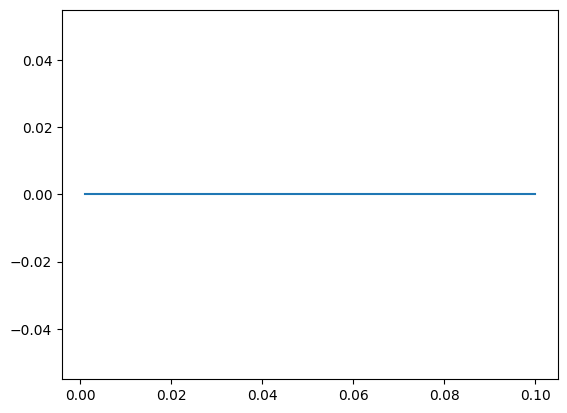

In [23]:
from matplotlib import pyplot as plt
#
plt.plot(tempo, energia)

# Exercício 14

<div style = "text-align: justify; font-size: 24px;">
    Importe o arquivo "energia_cinetica.csv" gravado anteriormente e faça um gráfico da energia em função do tempo.
</div>

# Exercício 15

<div style = "text-align: justify; font-size: 24px;">
    Importe o arquivo "forca_maxima.csv" gravado anteriormente e faça um gráfico da força em função do tempo.
</div>

# Ciclo MD

<div style = "text-align: justify; font-size: 24px;">
    É possível salvar o sistema físico após a simulação para trabalhos posteriores usando o método <code>save()</code>.
</div>
<div class = "alert alert-block alert-warning" style = "font-size: 24px; text-align: justify;">
    <b>Aviso: </b>Antes de salvar o sistema, é recomendável retornar os valores das unidades de medida para o sistema de coordenadas de entrada utilizando o método `convertUnitsInv()`.
</div>

In [ ]:
# convertendo para as unidades de medida de entrada
sistema.convertUnitsInv()

In [ ]:
# salvando sistema em arquivo JSON
#sistema.save('sistema.json')

# Exercício 16

<div style = "text-align: justify; font-size: 24px;">
    Salve a sua simulação em um arquivo JSON com o nome "simulacao_nova.json" utilizando o método save(). Observe que você pode salvar a simulação sem alterar o sistema original.
</div>

# Exercício 17

<div style = "text-align: justify; font-size: 24px;">
    Repita a simulação do gás de argônio, mas considere um timestep de $5\times 10^{-4}\; ps$ e um intervalo de tempo de 5000 ps. Faça uma cópia de segurança à cada 100 ps. (Esta estratégia é útil em situações como quedas de energia, queima do disco rígido e outras enventuais surpresas que podem interromper a simulação antes do previsto.)
</div>

# Propriedades físico-químicas

<div style = "font-size: 24px;">
    <ul>
        <li>Estrutural</li>
        <li>Dinâmico</li>
        <li>Vibracional</li>
        <li>Termodinâmico</li>
        <li>Eletromagnético</li>
    </ul>
</div>

# Propriedades físico-químicas

## Estrutural

### Função de distribuição radial

<div style = "display: flex;">
    <div style = "align: center; margin-right: 40px">
        <img src = "rdf.jpeg" alt="placeholder" width="1000px" height="1000px">
    </div>
    <div style = "text-align: left; font-size: 24px;">
        A função de distribuição radial g(r) fornece a probabilidade de se encontrar uma partícula em uma camada esférica de espessura dr, a uma distância r de outra partícula,
            $$g(r) = \frac{\left<\rho(r)\right>}{\rho},$$
    $\rho(r)$ representa o número de moléculas no volume $4\pi r^2 dr$.
    </div>
</div>
<footer style = "text-align: center;">
<a>Morgon, N. H.; Coutinho, K. Métodos de Química teórica e Modelagem Molecular, ed.1, São Paulo: Editora Livraria da Física, 2007.</a>
</footer>

# Propriedades físico-químicas

## Estrutural

### Compressibilidade isotérmica

<div style = "text-align: justify; font-size: 24px;">
    A compressibilidade isotérmica é obtida na forma
    $$\kappa = \frac{1}{k_BT}\frac{\left(\left<V^2\right>-\left<V\right>^2\right)}{\left<V\right>}$$
</div>

# Propriedades físico-químicas

## Dinâmico

### Coeficiente de difusão

<div style = "text-align: justify; font-size: 24px;">
    O coeficiente de difusão pode ser obtido a partir do deslocamento médio quadrático, como mostra a equação abaixo,
    $$D = {Lim \atop t\rightarrow \infty}\frac{\left<\vec{r}(t)-\vec{r}(0)\right>}{6t}$$
</div>

# Propriedades físico-químicas

## Termodinâmico

### Calor específico

<div style = "text-align: justify; font-size: 24px;">
    Capacidade térmica e o calor específico podem ser facilmente obtidos a partir da flutuação da energia interna do sistema,
    $$C_V = C_V^{ideal}+\frac{1}{k_BT^2}\left(\left<U^2\right>-\left<U\right>^2\right)$$
</div>